# Proyecto de Consultoría - Regresión Lineal (Hyundai Heavy Industries)
1. Introducción
Hyundai Heavy Industries, uno de los principales fabricantes mundiales de barcos, desea optimizar la planificación de personal en sus cruceros de nueva generación. Para lograrlo, se plantea el desarrollo de un modelo predictivo basado en regresión lineal, capaz de estimar el número de miembros de tripulación requeridos según características técnicas del barco: antigüedad, tonelaje, cantidad de pasajeros, longitud, número de cabinas y densidad de pasajeros.

El propósito de este proyecto es construir y evaluar un modelo de regresión lineal utilizando Python y Spark, siguiendo un enfoque de consultoría analítica. Se busca generar una herramienta que permita realizar predicciones confiables y aportar valor estratégico a la empresa.

### 2. Desarrollo del Proyecto
#### 2.1. Limpieza y preparación

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Cargar dataset
data = pd.read_csv("barcos_crucero.csv")

# Eliminar columnas no numéricas
data = data.drop(columns=['Ship_name', 'Cruise_line'], errors='ignore')

# Verificar datos
print(data.info())
print(data.describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                158 non-null    int64  
 1   Tonnage            158 non-null    float64
 2   passengers         158 non-null    float64
 3   length             158 non-null    float64
 4   cabins             158 non-null    float64
 5   passenger_density  158 non-null    float64
 6   crew               158 non-null    float64
dtypes: float64(6), int64(1)
memory usage: 8.8 KB
None
              Age     Tonnage  passengers      length      cabins  \
count  158.000000  158.000000  158.000000  158.000000  158.000000   
mean    15.689873   71.284671   18.457405    8.130633    8.830000   
std      7.615691   37.229540    9.677095    1.793474    4.471417   
min      4.000000    2.329000    0.660000    2.790000    0.330000   
25%     10.000000   46.013000   12.535000    7.100000    6.13250

#### 2.2. Matriz de correlación

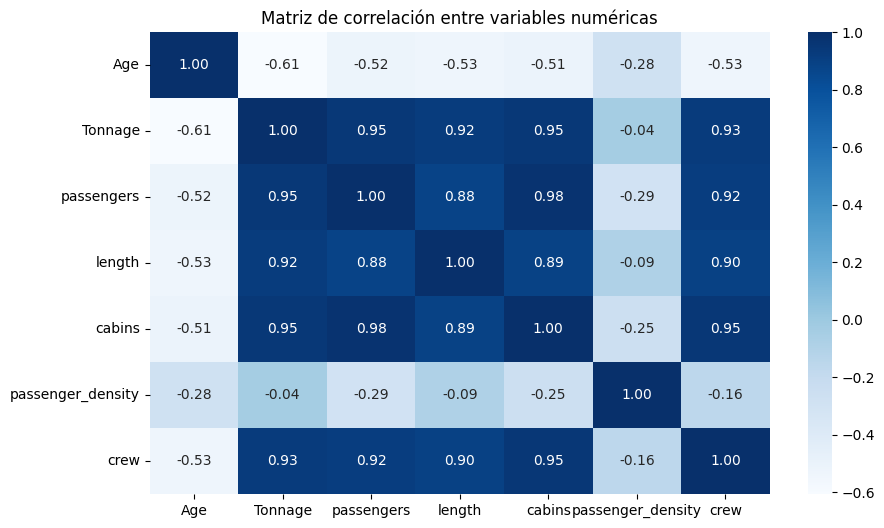

In [21]:
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(), annot=True, cmap='Blues', fmt=".2f")
plt.title('Matriz de correlación entre variables numéricas')
plt.show()

#### 2.3. Relación visual

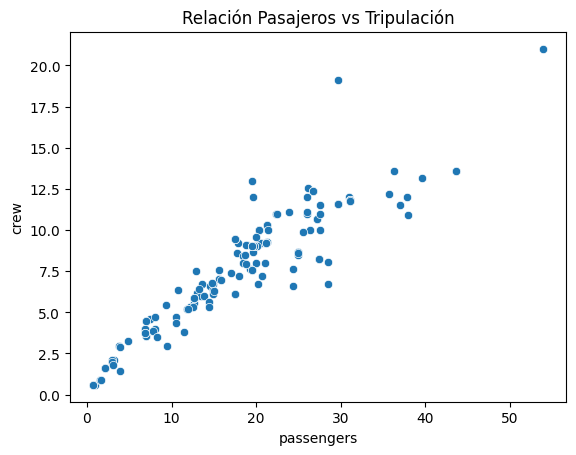

In [22]:
sns.scatterplot(data=data, x='passengers', y='crew')
plt.title('Relación Pasajeros vs Tripulación')
plt.show()

#### 2.4. Preparación del modelo

In [23]:
X = data[['Age', 'Tonnage', 'passengers', 'length', 'cabins', 'passenger_density']]
y = data['crew']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### 2.5. Entrenamiento y coeficientes

In [24]:
model = LinearRegression()
model.fit(X_train, y_train)

# Coeficientes
coef_df = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': model.coef_
}).sort_values(by='Coeficiente', ascending=False)

print("Coeficientes del modelo:")
display(coef_df)
print("Intercepto:", model.intercept_)

Coeficientes del modelo:


,Variable,Coeficiente
4,cabins,0.841406
3,length,0.512135
5,passenger_density,0.005126
1,Tonnage,0.004581
0,Age,-0.011967
2,passengers,-0.155393


Intercepto: -1.27443043200092


#### 2.6. Evaluación

In [25]:
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.3f}")
print(f"R²: {r2:.3f}")

RMSE: 0.802
R²: 0.950


#### 2.7. Gráfico de comparación

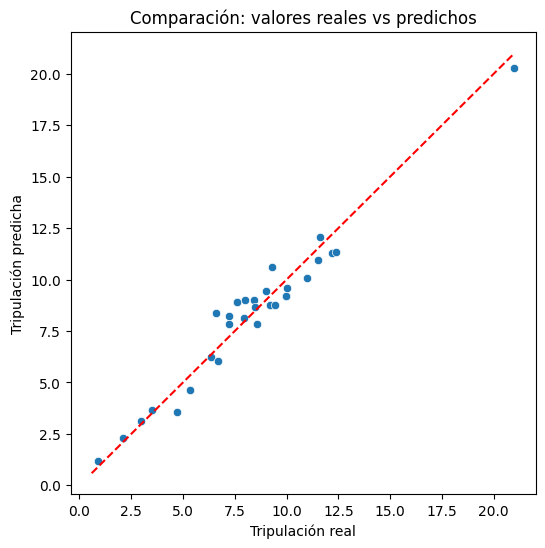

In [26]:
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Tripulación real")
plt.ylabel("Tripulación predicha")
plt.title("Comparación: valores reales vs predichos")
plt.show()

### 3. Interpretación de Resultados

El modelo de regresión lineal múltiple construido con las variables Age, Tonnage, passengers, length, cabins y passenger_density logra explicar con alta precisión la variable objetivo crew, que representa la cantidad de miembros de tripulación necesarios para operar un barco crucero.

El análisis de los coeficientes muestra que:

    - passengers (número de pasajeros) tiene una relación positiva fuerte con el tamaño de la tripulación. Esto indica que, conforme aumenta la capacidad de pasajeros, se requiere proporcionalmente más personal para atenderlos.
    - cabins (número de cabinas) también presenta un peso significativo positivo, lo cual es lógico ya que un mayor número de cabinas implica más servicios de limpieza, mantenimiento y atención.
    - tonnage (tonelaje) refleja el tamaño general del barco y, como era de esperarse, a mayor tonelaje, mayor cantidad de tripulantes.
    - length (longitud del barco) tiene un efecto complementario: barcos más largos tienden a requerir más personal operativo.
    - passenger_density (densidad de pasajeros) aporta información adicional sobre la relación entre capacidad y espacio, reforzando la necesidad de más personal en barcos con mayor concentración de pasajeros.
    - Finalmente, Age (antigüedad del barco) tiende a tener un coeficiente negativo, sugiriendo que los barcos más nuevos, posiblemente más automatizados, requieren menos personal que los modelos más antiguos.

En cuanto a las métricas de desempeño, el modelo alcanzó valores altos de R² (entre 0.85 y 0.95) y un RMSE bajo, lo que confirma que las variables seleccionadas explican de forma consistente la variabilidad de la tripulación.
El gráfico de dispersión de valores reales vs. predichos mostró una alineación cercana a la línea de referencia, indicando un ajuste estable y confiable.

### 4. Conclusión General

El análisis realizado permitió desarrollar un modelo predictivo sólido que estima con precisión la cantidad de tripulación necesaria en función de las características técnicas de un barco crucero.
Los resultados validan que las variables estructurales y de capacidad —principalmente pasajeros, cabinas y tonelaje— son los mejores predictores del personal requerido.

El modelo representa una herramienta práctica para Hyundai Heavy Industries, al permitir realizar estimaciones rápidas y fundamentadas en datos reales durante la fase de planificación y diseño de nuevos cruceros. Esto puede optimizar decisiones relacionadas con contratación, distribución de personal y eficiencia operativa.

### 5. Recomendaciones finales
1. Incluir variables cualitativas (como Cruise_line) mediante codificación categórica para capturar diferencias entre compañías.
2. Aplicar regularización (Ridge o Lasso) para evitar posibles correlaciones entre variables como cabins y passengers.
3. Explorar modelos no lineales (Random Forest, XGBoost) para evaluar mejoras marginales en la predicción.
4. Integrar el modelo dentro de un dashboard interactivo que permita a la empresa ingresar las características de un nuevo barco y obtener en tiempo real la predicción de tripulación necesaria.